In [2]:
# 0 PREPARACION DE ENTORNO DE TRABAJO

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#0.1 Configuración de Gráficos

In [5]:
%matplotlib inline
sns.set(style="whitegrid")

In [6]:
# 1 CARGA DEL DATASET

In [7]:
df = pd.read_csv(r"C:\Users\Administrador\Downloads\SECOP_II_-_Contratos_Electronicos_20260220.csv")
df.head()

C:\Users\Administrador\AppData\Local\Temp\ipykernel_18072\1779487131.py:1: DtypeWarning: Columns (48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Administrador\Downloads\SECOP_II_-_Contratos_Electronicos_20260220.csv")


,Nombre Entidad,Nit Entidad,Departamento,Ciudad,Localización,Orden,Sector,Rama,Entidad Centralizada,Proceso de Compra,...,Tipo de documento Ordenador del gasto,Número de documento Ordenador del gasto,Nombre supervisor,Tipo de documento supervisor,Número de documento supervisor,Nombre Ordenador de Pago,Tipo de documento Ordenador de Pago,Número de documento Ordenador de Pago,Documentos Tipo,Descripcion Documentos Tipo
0,JEP,"901,140,004",Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,No aplica/No pertenece,Corporación Autónoma,Centralizada,CO1.BDOS.1108279,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido
1,ALCALDIA MUNICIPIO DE ARAUCA,"800,102,504",Arauca,Arauca,"Colombia, Arauca , Arauca",Territorial,Servicio Público,Ejecutivo,Descentralizada,CO1.BDOS.3106524,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido
2,SECRETARIA GENERAL Y DE CERCANIA AL CIUDADANO,"899,999,114",Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,No aplica/No pertenece,Ejecutivo,Centralizada,CO1.BDOS.9463073,...,Cédula de Ciudadanía,35.355.189,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido
3,ALCALDIA MUNICIPAL DE VALLEDUPAR,"800,098,911",Cesar,Valledupar,"Colombia, Cesar , Valledupar",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.2250151,...,Cédula de Ciudadanía,1065578810,LUIS ENRIQUE GALVIS NUÑEZ,Cédula de Ciudadanía,77186812,No definido,No definido,No definido,No,No definido
4,MINISTERIO DE MINAS Y ENERGIA,"899,999,022",Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Minas y Energía,Ejecutivo,Centralizada,CO1.BDOS.4621217,...,Cédula de Ciudadanía,52533268,LUISA FERNANDA PARIS JARAMILLO,Cédula de Ciudadanía,1018481800,No definido,No definido,No definido,No,No definido


In [8]:
df. shape

(2953605, 87)

In [9]:
# 1.1 Revisión de Columnas

In [10]:
df.columns

Index(['Nombre Entidad', 'Nit Entidad', 'Departamento', 'Ciudad',
       'Localización', 'Orden', 'Sector', 'Rama', 'Entidad Centralizada',
       'Proceso de Compra', 'ID Contrato', 'Referencia del Contrato',
       'Estado Contrato', 'Codigo de Categoria Principal',
       'Descripcion del Proceso', 'Tipo de Contrato',
       'Modalidad de Contratacion', 'Justificacion Modalidad de Contratacion',
       'Fecha de Firma', 'Fecha de Inicio del Contrato',
       'Fecha de Fin del Contrato', 'Condiciones de Entrega',
       'TipoDocProveedor', 'Documento Proveedor', 'Proveedor Adjudicado',
       'Es Grupo', 'Es Pyme', 'Habilita Pago Adelantado', 'Liquidación',
       'Obligación Ambiental', 'Obligaciones Postconsumo', 'Reversion',
       'Origen de los Recursos', 'Destino Gasto', 'Valor del Contrato',
       'Valor de pago adelantado', 'Valor Facturado',
       'Valor Pendiente de Pago', 'Valor Pagado', 'Valor Amortizado',
       'Valor Pendiente de Amortizacion', 'Valor Pendiente de Ej

In [11]:
# 1.2 Validación de columnas mínimas requeridas para el análisis

In [12]:
columnas_minimas = [
    'Proveedor Adjudicado',
    'TipoDocProveedor',
    'Fecha de Inicio del Contrato',
    'Fecha de Fin del Contrato',
    'Valor del Contrato',
    'Tipo de Contrato',
    'Estado Contrato'
]

faltantes = [col for col in columnas_minimas if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas mínimas están presentes")
else:
    print("Columnas faltantes:", faltantes)

Todas las columnas mínimas están presentes


In [13]:
# 2. LIMPIEZA Y PREPARACION DE DATOS 

In [14]:
# 2.1 Eliminaciòn de registros duplicados

In [15]:
duplicados = df.duplicated().sum()
print("Duplicados encontrados:", duplicados)

df = df.drop_duplicates().copy()

print("Nuevo tamaño del dataset:", df.shape)

Duplicados encontrados: 956
Nuevo tamaño del dataset: (2952649, 87)


In [16]:
#2.2 Revisión de Valores Nulos 

In [17]:
nulos = df.isna().sum().sort_values(ascending=False)

nulos[nulos > 0].head(15)

Fecha de notificación de prorrogación    2662771
Fecha Fin Liquidacion                    2621978
Fecha Inicio Liquidacion                 2621961
Ultima Actualizacion                     1391111
Fecha de Inicio del Contrato              252713
Fecha de Firma                            211710
Fecha de Fin del Contrato                  28315
Domicilio Representante Legal                108
Número de cuenta                              84
Referencia del Contrato                       70
Nombre del banco                              53
Documento Proveedor                           24
Nacionalidad Representante Legal              20
Proveedor Adjudicado                          17
Objeto del Contrato                           13
dtype: int64

In [18]:
columnas_clave = [
    'Proveedor Adjudicado',
    'Fecha de Inicio del Contrato',
    'Fecha de Fin del Contrato',
    'Valor del Contrato',
    'Tipo de Contrato',
    'Estado Contrato'
]

df[columnas_clave].isna().sum()

Proveedor Adjudicado                17
Fecha de Inicio del Contrato    252713
Fecha de Fin del Contrato        28315
Valor del Contrato                   5
Tipo de Contrato                     5
Estado Contrato                      5
dtype: int64

In [19]:
# 2.2.1 Depueación de valores nulos

In [20]:
df = df.dropna(subset=[
    'Proveedor Adjudicado',
    'Fecha de Fin del Contrato'
]).copy()

print("Nuevo tamaño tras limpieza:", df.shape)

Nuevo tamaño tras limpieza: (2924322, 87)


In [21]:
# 2.3 Conversión de variables de fecha 

In [22]:
df['Fecha de Inicio del Contrato'] = pd.to_datetime(
    df['Fecha de Inicio del Contrato'],
    errors='coerce'
)

df['Fecha de Fin del Contrato'] = pd.to_datetime(
    df['Fecha de Fin del Contrato'],
    errors='coerce'
)

df[['Fecha de Inicio del Contrato','Fecha de Fin del Contrato']].head()

,Fecha de Inicio del Contrato,Fecha de Fin del Contrato
0,2020-02-13,2020-12-21
1,2022-08-05,2022-12-27
2,2026-01-19,2026-11-18
3,2021-09-16,2021-12-15
4,NaT,2023-12-31


In [23]:
df[['Fecha de Inicio del Contrato','Fecha de Fin del Contrato']].dtypes

Fecha de Inicio del Contrato    datetime64[ns]
Fecha de Fin del Contrato       datetime64[ns]
dtype: object

In [24]:
df[['Fecha de Inicio del Contrato','Fecha de Fin del Contrato']].isna().sum()

Fecha de Inicio del Contrato    224405
Fecha de Fin del Contrato           23
dtype: int64

In [25]:
# 2.4 Selección y Validación de Rango de fechas para analisis (2022- 2025)

In [26]:
df = df[
    (df['Fecha de Inicio del Contrato'] >= '2022-01-01') &
    (df['Fecha de Inicio del Contrato'] <= '2025-12-31')
].copy()

In [27]:
df['Fecha de Inicio del Contrato'].min(), df['Fecha de Inicio del Contrato'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [28]:
df['Fecha de Inicio del Contrato'].isna().sum()

0

In [29]:
df. shape

(1813598, 87)

In [30]:

df['Fecha de Inicio del Contrato'].dt.year.value_counts().sort_index()

Fecha de Inicio del Contrato
2022    370164
2023    439602
2024    466933
2025    536899
Name: count, dtype: int64

In [31]:
# 2.5 Conversión y estandarización de variables en valores de los contratos
# 2.5.1 Diagnóstico de "Valor del Contrato"

In [32]:
print("dtype:", df["Valor del Contrato"].dtype)
df["Valor del Contrato"].head(10)

dtype: object


1         $6,673,341
5        $27,723,175
6       $131,654,600
8        $14,000,000
10       $13,646,667
12       $18,715,790
13       $24,483,333
16       $74,604,735
17    $2,513,909,919
18       $10,638,000
Name: Valor del Contrato, dtype: object

In [33]:
df["Valor del Contrato"].astype(str).sample(10, random_state=42)

2612265       $61,224,000
101920     $1,779,648,903
1912652       $28,710,000
1648956       $30,000,000
60671         $13,995,888
2793700       $12,000,000
1115023      $114,552,000
1941532        $2,550,000
1997640       $10,800,000
2791355       $52,848,340
Name: Valor del Contrato, dtype: object

In [34]:
# 2.5.2 Limpieza y conversión de "Valor del Contrato"

In [35]:

df["Valor del Contrato_raw"] = df["Valor del Contrato"]


df["Valor del Contrato"] = (
    df["Valor del Contrato"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)


df["Valor del Contrato"] = pd.to_numeric(df["Valor del Contrato"], errors="coerce")

print("dtype final:", df["Valor del Contrato"].dtype)
print("Nulos tras conversión:", df["Valor del Contrato"].isna().sum())

df["Valor del Contrato"].describe()

dtype final: int64
Nulos tras conversión: 0


count    1.813598e+06
mean     1.745188e+08
std      5.293007e+09
min      0.000000e+00
25%      9.800000e+06
50%      1.960000e+07
75%      4.031183e+07
max      4.205028e+12
Name: Valor del Contrato, dtype: float64

In [36]:
# 2.5.3 Validaciones del Valor del Contrato

In [37]:
negativos = (df["Valor del Contrato"] < 0).sum()
ceros = (df["Valor del Contrato"] == 0).sum()

print("Valores negativos:", negativos)
print("Valores en cero:", ceros)

df["Valor del Contrato"].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

Valores negativos: 0
Valores en cero: 11949


0.50    1.960000e+07
0.75    4.031183e+07
0.90    9.009000e+07
0.95    2.300000e+08
0.99    2.228302e+09
Name: Valor del Contrato, dtype: float64

In [38]:
# 2.6 Selección de Contratos en Estados Activos 

In [39]:
df['Estado Contrato'].value_counts()

Estado Contrato
En ejecución         674351
Cerrado              467012
Modificado           393903
terminado            265632
cedido                 9244
Suspendido             3123
Aprobado                294
Cancelado                28
Borrador                  9
enviado Proveedor         2
Name: count, dtype: int64

In [40]:
estados_activos = [
    'En ejecución',
    'Aprobado',
    'En aprobación',
    'Prorrogado',
    'Enviado Proveedor',
    'Modificado'
]

In [78]:
df_activos = df[
    df['Estado Contrato'].isin(estados_activos)
].copy()

In [79]:
df_activos.shape

(1068548, 90)

In [80]:
#2.7 Eliminación de contratos sin fechas validas 

In [81]:
df_activos = df_activos[
    df_activos['Fecha de Inicio del Contrato'].notna() &
    df_activos['Fecha de Fin del Contrato'].notna()
].copy()

df_activos.shape

(1068537, 90)

In [82]:
#2.8 Selección de Modalides de contratación de interes 

In [83]:
df['Tipo de Contrato'].value_counts()

Tipo de Contrato
Prestación de servicios           1552295
Otro                                69665
Decreto 092 de 2017                 66637
Suministros                         44680
Compraventa                         33724
Obra                                16123
Arrendamiento de inmuebles          13382
Interventoría                        4166
Seguros                              3714
Consultoría                          3610
Comodato                             3445
Arrendamiento de muebles              649
Servicios financieros                 394
Acuerdo Marco de Precios              320
Operaciones de Crédito Público        183
No Especificado                       172
Venta muebles                         140
Asociación Público Privada             82
Comisión                               67
Negocio fiduciario                     55
Concesión                              43
No Definido                            35
Venta inmuebles                        17
Name: count, dtyp

In [84]:
tipos_objetivo = [
    'Prestación de servicios',
    'Obra',
    'Consultorîa',
    'Interventoria',
    'Comisión'
]

df_filtrado = df_activos[df_activos['Tipo de Contrato'].isin(tipos_objetivo)].copy()
df_filtrado.shape

(907469, 90)

In [85]:
# 2.9 Normalización de Identificadores de Proveedor

In [86]:
df_sim = df_filtrado[[
    'Proveedor Adjudicado',
    'TipoDocProveedor',
    'Fecha de Inicio del Contrato',
    'Fecha de Fin del Contrato',
    'Valor del Contrato',
    'Tipo de Contrato',
    'Estado Contrato'
]].copy()

df_sim.shape

(907469, 7)

In [87]:
df_sim['Proveedor Adjudicado'] = (
    df_sim['Proveedor Adjudicado']
        .str.upper()
        .str.strip()
)

In [88]:
# 2.10 Depuración y clasificacion de proveedores empresarilales por NIT

In [89]:
mask_nit = (
    df_sim['TipoDocProveedor']
        .astype(str)
        .str.upper()
        .str.contains('NIT', na=False)
)

mask_no_nat = ~(
    df_sim['Proveedor Adjudicado']
        .astype(str)
        .str.upper()
        .isin(['PERSONA NATURAL', 'SIN DESCRIPCION', 'PROVEEDOR'])
)

df_empresas = df_sim[mask_nit & mask_no_nat].copy()

df_empresas.shape

(72144, 7)

In [90]:
# 3. ANALISIS EXPLORATORIO

In [91]:
# 3.1 Distribución de Valores Contractuales

C:\Users\Administrador\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


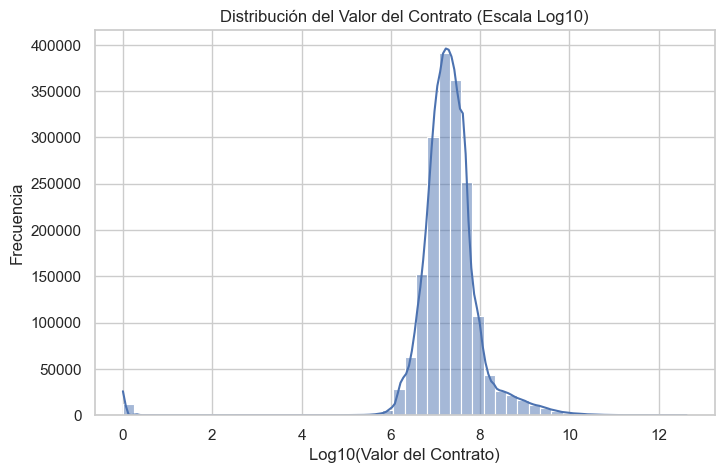

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["Valor_log"] = np.log10(df["Valor del Contrato"] + 1)

plt.figure(figsize=(8,5))
sns.histplot(df["Valor_log"], bins=50, kde=True)
plt.title("Distribución del Valor del Contrato (Escala Log10)")
plt.xlabel("Log10(Valor del Contrato)")
plt.ylabel("Frecuencia")
plt.show()

In [93]:
#3.2 Cantidad de Contratos por Contratista

In [94]:
contratos_por_proveedor = (
    df.groupby("Proveedor Adjudicado")
      .size()
      .sort_values(ascending=False)
)

contratos_por_proveedor.head(10)

Proveedor Adjudicado
Aseguradora Solidaria de Colombia Entidad Cooperativa.                                     1332
LA PREVISORA S.A. COMPAÑÍA DE SEGUROS                                                      1224
SERVICIOS POSTALES NACIONALES S.A.S                                                         749
INSTITUTO COLOMBIANO DE NORMAS TÉCNICAS Y CERTIFICACIÓN                                     637
SEGUROS DEL ESTADO S.A.                                                                     565
IMPRENTA NACIONAL DE COLOMBIA                                                               555
DISTRIBUIDORA COLOMBIANA DE MEDICAMENTOS  Y TECNOLOGIAS EN SALUD SAS - DISCOLMETS S.A.S     554
FOMCULTURA                                                                                  537
UNIVERSIDAD DE ANTIOQUIA                                                                    495
Sin Descripcion                                                                             472
dtype: int64

C:\Users\Administrador\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


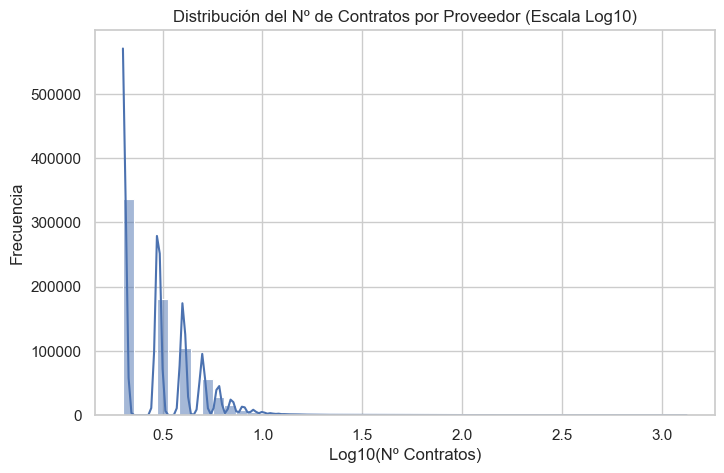

In [95]:
plt.figure(figsize=(8,5))

sns.histplot(np.log10(contratos_por_proveedor + 1), bins=50, kde=True)

plt.title("Distribución del Nº de Contratos por Proveedor (Escala Log10)")
plt.xlabel("Log10(Nº Contratos)")
plt.ylabel("Frecuencia")

plt.show()

In [96]:
# 3.3 Detección de Outliers 

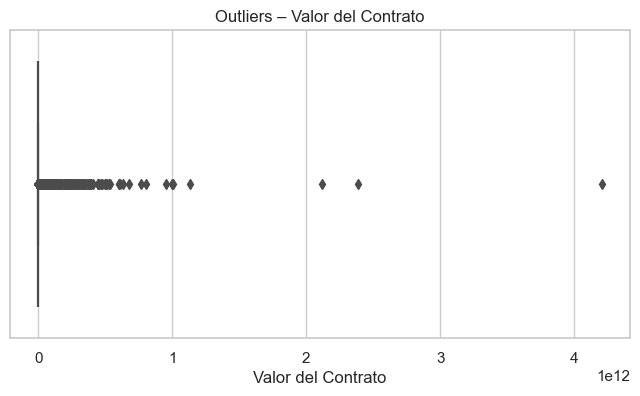

In [97]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Valor del Contrato"])
plt.title("Outliers – Valor del Contrato")
plt.show()

In [98]:
# 3.4 Corelaciones Numèricas 

In [99]:
vars_numericas = df.select_dtypes(include=["int64","float64"])

vars_numericas = vars_numericas.drop(columns=["Codigo Proveedor"])

<Axes: >

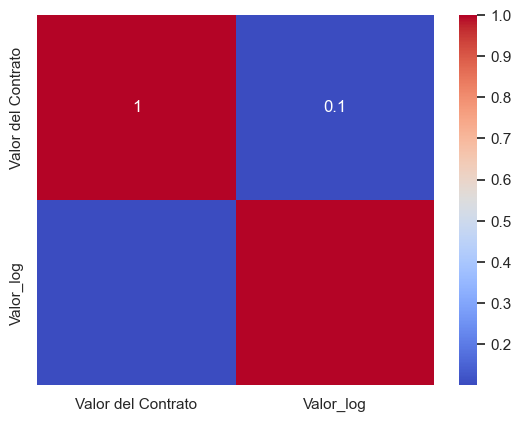

In [100]:
sns.heatmap(vars_numericas.corr(), cmap="coolwarm", annot=True)

In [101]:
# 4. INGENIERIA DE VARIABLES 

In [102]:
# 4.1 Definición de fecha de corte para evaluación de vigencia contractual

In [103]:
fecha_corte = pd.Timestamp("2025-12-31")
fecha_corte

Timestamp('2025-12-31 00:00:00')

In [104]:
# 4.2 Variable Vugencia cotractual a la fecha de corte

In [105]:
df["Contrato_Vigente"] = (
    (df["Fecha de Inicio del Contrato"] <= fecha_corte) &
    (df["Fecha de Fin del Contrato"] >= fecha_corte)
).astype(int)

# Validación
df["Contrato_Vigente"].value_counts(dropna=False)

Contrato_Vigente
0    1628954
1     184644
Name: count, dtype: int64

In [106]:
df.loc[df["Contrato_Vigente"]==1, ["Proveedor Adjudicado","Fecha de Inicio del Contrato","Fecha de Fin del Contrato","Valor del Contrato"]].head(10)

,Proveedor Adjudicado,Fecha de Inicio del Contrato,Fecha de Fin del Contrato,Valor del Contrato
6,Carlos Andres Suárez Méndez,2025-01-29,2025-12-31,131654600
50,Yenny Alexandra Camargo Magin,2025-01-28,2025-12-31,134679932
69,Junta de Accion Comunal Barrio La Esperanza,2024-11-12,2026-08-30,168750000
84,ASOCIACIÓN DE TRABAJADORES DEL SISTEMA EDUCATI...,2025-04-10,2026-03-29,7520632494
122,Carolina Moncada Deosa,2025-03-25,2025-12-31,47333333
183,ASOCIACION DE SEMBRADORES DEL MAGDALENA J&J,2025-12-31,2026-07-31,705637372
194,FIDUCIARIA POPULAR S.A,2025-07-03,2026-04-02,38817800
197,JAKO IMPORTACIONES SAS,2024-12-01,2026-07-31,427914142
201,DIANA CECILIA PEÑA MINA,2025-04-09,2025-12-31,56083500
210,EMPRESA DE DESARROLLO DE SAN CARLOS,2025-05-09,2025-12-31,444202123


In [107]:
# 4.3 Carga contractual vigente por proveedor

In [108]:

carga_vigente = (
    df[df["Contrato_Vigente"] == 1]
    .groupby("Proveedor Adjudicado")["Valor del Contrato"]
    .sum()
    .sort_values(ascending=False)
)

# Ver top 10 proveedores con mayor carga vigente
carga_vigente.head(10)

Proveedor Adjudicado
GECELCA S.A. E.S.P.                                           4205027751839
FINANCIERA DE DESARROLLO TERRITORIAL S.A.                     1814910849116
EMPRESA DE DESARROLLO URBANO DE MEDELLIN                      1746705565623
ESU                                                           1710946778954
INSTITUTO PARA EL DESARROLLO DE ANTIOQUIA IDEA                1706799142050
Banco Davivienda                                              1494573660621
Oficina de las Naciones Unidas contra la Droga y el Delito    1257075416615
INGREDION COLOMBIA SA                                         1135008102785
AGENCIA LOGISTICA DE LAS FUERZAS MILITARES                    1126246177877
SERVICIOS POSTALES NACIONALES S.A.S                           1019649259697
Name: Valor del Contrato, dtype: int64

In [109]:
carga_vigente = carga_vigente.reset_index()
carga_vigente.columns = ["Proveedor Adjudicado", "Carga_Contractual_Vigente"]

carga_vigente.head()

,Proveedor Adjudicado,Carga_Contractual_Vigente
0,GECELCA S.A. E.S.P.,4205027751839
1,FINANCIERA DE DESARROLLO TERRITORIAL S.A.,1814910849116
2,EMPRESA DE DESARROLLO URBANO DE MEDELLIN,1746705565623
3,ESU,1710946778954
4,INSTITUTO PARA EL DESARROLLO DE ANTIOQUIA IDEA,1706799142050


In [110]:
carga_vigente.describe()

,Carga_Contractual_Vigente
count,1.535370e+05
mean,8.231038e+08
std,1.956095e+10
min,0.000000e+00
25%,1.486040e+07
50%,3.128462e+07
75%,6.534000e+07
max,4.205028e+12


In [111]:
# 4.4 Número de contratos vigentes por proveedor

In [112]:

contratos_vigentes = (
    df[df["Contrato_Vigente"] == 1]
    .groupby("Proveedor Adjudicado")
    .size()
    .sort_values(ascending=False)
)

contratos_vigentes.head(10)

Proveedor Adjudicado
Aseguradora Solidaria de Colombia Entidad Cooperativa.    271
LA PREVISORA S.A. COMPAÑÍA DE SEGUROS                     265
SERVICIOS POSTALES NACIONALES S.A.S                       177
IMPRENTA NACIONAL DE COLOMBIA                             131
SEGUROS DEL ESTADO S.A.                                   119
UNIVERSIDAD NACIONAL DE COLOMBIA                           95
INSTITUTO TECNOLOGICO METROPOLITANO                        91
UNIVERSIDAD DE ANTIOQUIA                                   82
BANCO POPULAR                                              76
INSTITUTO PARA EL DESARROLLO DE ANTIOQUIA IDEA             73
dtype: int64

In [113]:
contratos_vigentes = contratos_vigentes.reset_index()
contratos_vigentes.columns = ["Proveedor Adjudicado", "Num_Contratos_Vigentes"]

contratos_vigentes.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes
0,Aseguradora Solidaria de Colombia Entidad Coop...,271
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265
2,SERVICIOS POSTALES NACIONALES S.A.S,177
3,IMPRENTA NACIONAL DE COLOMBIA,131
4,SEGUROS DEL ESTADO S.A.,119


In [114]:
contratos_vigentes.describe()

,Num_Contratos_Vigentes
count,153537.000000
mean,1.202603
std,1.874026
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,271.000000


In [115]:
# 4.5 Construir base de indicadores por proveedor

In [116]:
 df_features = contratos_vigentes.merge( 
    carga_vigente,
    on="Proveedor Adjudicado",
    how="left"
)
df_features.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes,Carga_Contractual_Vigente
0,Aseguradora Solidaria de Colombia Entidad Coop...,271,68258927834
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265,191602822672
2,SERVICIOS POSTALES NACIONALES S.A.S,177,1019649259697
3,IMPRENTA NACIONAL DE COLOMBIA,131,86331649398
4,SEGUROS DEL ESTADO S.A.,119,143701556536


In [117]:
df_features = df_features.drop(columns=["index"], errors="ignore")
df_features.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes,Carga_Contractual_Vigente
0,Aseguradora Solidaria de Colombia Entidad Coop...,271,68258927834
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265,191602822672
2,SERVICIOS POSTALES NACIONALES S.A.S,177,1019649259697
3,IMPRENTA NACIONAL DE COLOMBIA,131,86331649398
4,SEGUROS DEL ESTADO S.A.,119,143701556536


In [118]:
df_features.describe()

,Num_Contratos_Vigentes,Carga_Contractual_Vigente
count,153537.000000,1.535370e+05
mean,1.202603,8.231038e+08
std,1.874026,1.956095e+10
min,1.000000,0.000000e+00
25%,1.000000,1.486040e+07
50%,1.000000,3.128462e+07
75%,1.000000,6.534000e+07
max,271.000000,4.205028e+12


In [119]:
if "Indice_Simultaneidad" not in df_features.columns:
    df_features["Indice_Simultaneidad"] = df_features["Num_Contratos_Vigentes"].astype(float)

df_features[["Num_Contratos_Vigentes", "Indice_Simultaneidad"]].head()

,Num_Contratos_Vigentes,Indice_Simultaneidad
0,271,271.0
1,265,265.0
2,177,177.0
3,131,131.0
4,119,119.0


In [120]:
sim_max = df_features["Num_Contratos_Vigentes"].max()

df_features["Indice_Simultaneidad"] = (
    df_features["Num_Contratos_Vigentes"] / sim_max
)

In [121]:
# 4.6 Indice de Concentración

In [122]:
df_features["Indice_Concentracion"] = (
    df_features["Carga_Contractual_Vigente"] /
    df_features["Num_Contratos_Vigentes"]
)

df_features.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes,Carga_Contractual_Vigente,Indice_Simultaneidad,Indice_Concentracion
0,Aseguradora Solidaria de Colombia Entidad Coop...,271,68258927834,1.000000,2.518780e+08
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265,191602822672,0.977860,7.230295e+08
2,SERVICIOS POSTALES NACIONALES S.A.S,177,1019649259697,0.653137,5.760730e+09
3,IMPRENTA NACIONAL DE COLOMBIA,131,86331649398,0.483395,6.590202e+08
4,SEGUROS DEL ESTADO S.A.,119,143701556536,0.439114,1.207576e+09


In [123]:
df_features.describe()

,Num_Contratos_Vigentes,Carga_Contractual_Vigente,Indice_Simultaneidad,Indice_Concentracion
count,153537.000000,1.535370e+05,153537.000000,1.535370e+05
mean,1.202603,8.231038e+08,0.004438,4.249716e+08
std,1.874026,1.956095e+10,0.006915,1.313570e+10
min,1.000000,0.000000e+00,0.003690,0.000000e+00
25%,1.000000,1.486040e+07,0.003690,1.445040e+07
50%,1.000000,3.128462e+07,0.003690,3.022985e+07
75%,1.000000,6.534000e+07,0.003690,6.037500e+07
max,271.000000,4.205028e+12,1.000000,4.205028e+12


In [124]:
# 4.7 Saturación Contractual

In [125]:
carga_max = df_features["Carga_Contractual_Vigente"].max()
carga_max

4205027751839

In [126]:
df_features["Saturacion_Contractual"] = (
    df_features["Carga_Contractual_Vigente"] / carga_max
)

df_features.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes,Carga_Contractual_Vigente,Indice_Simultaneidad,Indice_Concentracion,Saturacion_Contractual
0,Aseguradora Solidaria de Colombia Entidad Coop...,271,68258927834,1.000000,2.518780e+08,0.016233
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265,191602822672,0.977860,7.230295e+08,0.045565
2,SERVICIOS POSTALES NACIONALES S.A.S,177,1019649259697,0.653137,5.760730e+09,0.242483
3,IMPRENTA NACIONAL DE COLOMBIA,131,86331649398,0.483395,6.590202e+08,0.020531
4,SEGUROS DEL ESTADO S.A.,119,143701556536,0.439114,1.207576e+09,0.034174


In [127]:
df_features["Saturacion_Contractual"].describe()

count    153537.000000
mean          0.000196
std           0.004652
min           0.000000
25%           0.000004
50%           0.000007
75%           0.000016
max           1.000000
Name: Saturacion_Contractual, dtype: float64

In [128]:
# 4.8 Capacidad Residual Estimada

In [129]:
df_features.columns

Index(['Proveedor Adjudicado', 'Num_Contratos_Vigentes',
       'Carga_Contractual_Vigente', 'Indice_Simultaneidad',
       'Indice_Concentracion', 'Saturacion_Contractual'],
      dtype='object')

In [130]:
sim_min = df_features["Indice_Simultaneidad"].min()
sim_max = df_features["Indice_Simultaneidad"].max()

df_features["Simultaneidad_Normalizada"] = (
    (df_features["Indice_Simultaneidad"] - sim_min) /
    (sim_max - sim_min)
)

df_features["Simultaneidad_Normalizada"].describe()

count    153537.000000
mean          0.000750
std           0.006941
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Simultaneidad_Normalizada, dtype: float64

In [131]:
alpha = 0.5  # peso simultaneidad
beta = 0.5   # peso saturación

In [132]:
df_features["Capacidad_Residual_Estimada"] = 1 - (
    alpha * df_features["Simultaneidad_Normalizada"] +
    beta * df_features["Saturacion_Contractual"]
)

df_features.head()

,Proveedor Adjudicado,Num_Contratos_Vigentes,Carga_Contractual_Vigente,Indice_Simultaneidad,Indice_Concentracion,Saturacion_Contractual,Simultaneidad_Normalizada,Capacidad_Residual_Estimada
0,Aseguradora Solidaria de Colombia Entidad Coop...,271,68258927834,1.000000,2.518780e+08,0.016233,1.000000,0.491884
1,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,265,191602822672,0.977860,7.230295e+08,0.045565,0.977778,0.488329
2,SERVICIOS POSTALES NACIONALES S.A.S,177,1019649259697,0.653137,5.760730e+09,0.242483,0.651852,0.552832
3,IMPRENTA NACIONAL DE COLOMBIA,131,86331649398,0.483395,6.590202e+08,0.020531,0.481481,0.748994
4,SEGUROS DEL ESTADO S.A.,119,143701556536,0.439114,1.207576e+09,0.034174,0.437037,0.764395


In [133]:
df_features["Capacidad_Residual_Estimada"].describe()

count    153537.000000
mean          0.999527
std           0.004700
min           0.488329
25%           0.999991
50%           0.999996
75%           0.999998
max           1.000000
Name: Capacidad_Residual_Estimada, dtype: float64

In [134]:
# 5. MACHINE LEARNING

In [135]:
# 5.1 Clustering K-means 

In [136]:
# 5.1.1 Selección de variables para clustering

In [137]:
import numpy as np

df_features["Carga_Log"] = np.log1p(df_features["Carga_Contractual_Vigente"])
df_features["Concentracion_Log"] = np.log1p(df_features["Indice_Concentracion"])

In [138]:
variables_cluster = df_features[[
    "Indice_Simultaneidad",
    "Carga_Log",
    "Concentracion_Log",
    "Saturacion_Contractual"
]]

In [139]:
# 5.1.2 Escalado de variables

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(variables_cluster)

In [141]:
# 5.1.3 Método del Codo

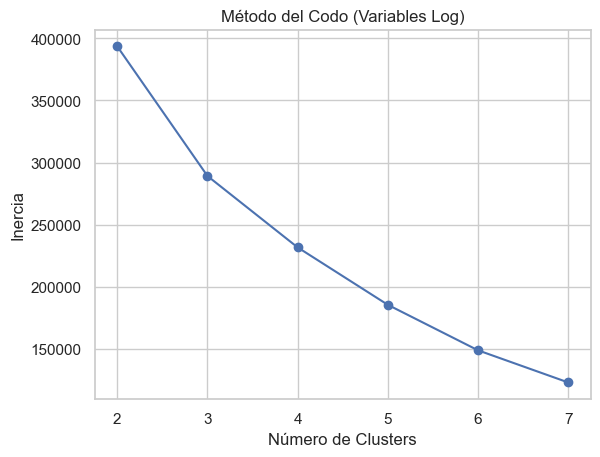

In [142]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(range(2,8), inercia, marker='o')
plt.title("Método del Codo (Variables Log)")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.show()

In [143]:
# 5.1.4 Entrenamiento del Modelo - 3 clusters

In [144]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_features["cluster_refinado"] = kmeans_final.fit_predict(X_scaled)

df_features["cluster_refinado"].value_counts()

cluster_refinado
0    150525
1      2735
2       263
3        14
Name: count, dtype: int64

In [145]:
# 5.1.5 Analisis de Clusters

In [146]:
df_features.groupby("cluster_refinado")[[
    "Indice_Simultaneidad",
    "Carga_Contractual_Vigente",
    "Saturacion_Contractual",
    "Capacidad_Residual_Estimada"
]].mean()

,Indice_Simultaneidad,Carga_Contractual_Vigente,Saturacion_Contractual,Capacidad_Residual_Estimada
cluster_refinado,,,,
0,0.004244,4.418976e+08,1.050879e-04,0.999669
1,0.004688,2.177697e+00,5.178792e-13,0.999499
2,0.104065,1.478628e+11,3.516333e-02,0.932045
3,0.166315,1.498024e+12,3.562460e-01,0.740263


In [147]:
# 5.1.6 Redefinición de  Clusters en Categorias

In [148]:
mapa = {
    0: "Bajo Riesgo",
    1: "Riesgo Bajo-Medio",
    2: "Riesgo Medio",
    3: "Riesgo Alto"
}

df_features["Nivel_Riesgo"] = df_features["cluster_refinado"].map(mapa)

In [149]:
df_features["Nivel_Riesgo"].value_counts()

Nivel_Riesgo
Bajo Riesgo          150525
Riesgo Bajo-Medio      2735
Riesgo Medio            263
Riesgo Alto              14
Name: count, dtype: int64

In [150]:
# 5.1.7 Cruce con capacidad Residual Promedio

In [151]:
df_features.groupby("Nivel_Riesgo")["Capacidad_Residual_Estimada"].mean()

Nivel_Riesgo
Bajo Riesgo          0.999669
Riesgo Alto          0.740263
Riesgo Bajo-Medio    0.999499
Riesgo Medio         0.932045
Name: Capacidad_Residual_Estimada, dtype: float64

In [152]:
# 5.2 Modelo Predictivo - Random Forest - Refresiòn

In [153]:
# 5.2.1 Definicion de Variables

In [154]:
X = df_features[[
    "Indice_Simultaneidad",
    "Carga_Log",
    "Concentracion_Log",
    "Saturacion_Contractual"
]]

y = df_features["Capacidad_Residual_Estimada"]

In [155]:
# 5.2.2 Entrenamiento del Modelo

In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [157]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [158]:
# 5.2.4 Predicción

In [159]:
y_pred = rf_reg.predict(X_test)

In [160]:
# 5.2.5 Evaluación 

In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 9.199200791950767e-06
RMSE: 0.0005954837050958106
R2: 0.9828603940232138


In [162]:
#5.2.6 Importancia de las Variables

In [163]:
importancias = pd.Series(
    rf_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

Indice_Simultaneidad      0.713352
Carga_Log                 0.156685
Saturacion_Contractual    0.114998
Concentracion_Log         0.014965
dtype: float64


In [164]:
# 5.2.7 Analisis de Robustes

In [165]:
X_reducido = df_features[[
    "Carga_Log",
    "Concentracion_Log",
    "Saturacion_Contractual"
]]

y = df_features["Capacidad_Residual_Estimada"]

In [166]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reducido, y, test_size=0.3, random_state=42
)

In [167]:
from sklearn.ensemble import RandomForestRegressor

rf_reg_reducido = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg_reducido.fit(X_train_r, y_train_r)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [168]:
y_pred_r = rf_reg_reducido.predict(X_test_r)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_r = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_r = r2_score(y_test_r, y_pred_r)

print("MAE reducido:", mae_r)
print("RMSE reducido:", rmse_r)
print("R2 reducido:", r2_r)

MAE reducido: 4.077350947498897e-05
RMSE reducido: 0.0017745804189567974
R2 reducido: 0.8477867565816678


In [169]:
# 5.3 Modelo predictivo - Random Forest - Clasificación

In [170]:
# 5.3.1 Definir variable objetivo - Riesgo

In [171]:
import pandas as pd

df_features["Nivel_Riesgo"] = pd.qcut(
    df_features["Capacidad_Residual_Estimada"],
    q=3,
    labels=["Alto", "Medio", "Bajo"]
)

df_features["Nivel_Riesgo"].value_counts()

Nivel_Riesgo
Alto     51180
Bajo     51179
Medio    51178
Name: count, dtype: int64

In [172]:
X = df_features[[
    "Indice_Simultaneidad",
    "Carga_Log",
    "Concentracion_Log",
    "Saturacion_Contractual"
]]

y = df_features["Nivel_Riesgo"]

In [173]:
# 5.3.2 División de Conjunto de Datos

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # importante para clasificación
)

In [175]:
# 5.3.3 Entrenamiento de Random Forest 

In [176]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [177]:
# 5.3.4 Evaluación

In [178]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9999131605227737

Classification Report:

              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00     15354
        Bajo       1.00      1.00      1.00     15354
       Medio       1.00      1.00      1.00     15354

    accuracy                           1.00     46062
   macro avg       1.00      1.00      1.00     46062
weighted avg       1.00      1.00      1.00     46062


Matriz de Confusión:

[[15352     0     2]
 [    0 15352     2]
 [    0     0 15354]]


In [179]:
# 5.3.5 Importancia de Variables 

In [180]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9999131605227737

Classification Report:

              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00     15354
        Bajo       1.00      1.00      1.00     15354
       Medio       1.00      1.00      1.00     15354

    accuracy                           1.00     46062
   macro avg       1.00      1.00      1.00     46062
weighted avg       1.00      1.00      1.00     46062


Matriz de Confusión:

[[15352     0     2]
 [    0 15352     2]
 [    0     0 15354]]


In [181]:
# 6. Evaluación del Modelo de Clustering

In [182]:
# 6.1 Cohesión y Separación de Clusters

In [183]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df_features["cluster_refinado"])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.9062180552164186


In [184]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np

# 1) toma una muestra (rápido y válido para decidir K)
sample_n = 20000  # si tu PC es lenta, pon 10000
idx = np.random.RandomState(42).choice(len(X_scaled), size=sample_n, replace=False)
X_s = X_scaled[idx]

k_values = range(2, 9)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_s)
    score = silhouette_score(X_s, labels)
    silhouette_scores.append(score)
    print(f"k={k}  silhouette={score:.4f}")

k=2  silhouette=0.9025
k=3  silhouette=0.9037
k=4  silhouette=0.9065
k=5  silhouette=0.6817
k=6  silhouette=0.6775
k=7  silhouette=0.5041
k=8  silhouette=0.5119


In [185]:
perfil_cluster = df_features.groupby("cluster_refinado")[
    ["Indice_Simultaneidad",
     "Carga_Contractual_Vigente",
     "Capacidad_Residual_Estimada"]
].agg(["mean","median","count"])

perfil_cluster

Indice_Simultaneidad                    \
                                 mean    median   count   
cluster_refinado                                          
0                            0.004244  0.003690  150525   
1                            0.004688  0.003690    2735   
2                            0.104065  0.084871     263   
3                            0.166315  0.136531      14   

                 Carga_Contractual_Vigente                        \
                                      mean        median   count   
cluster_refinado                                                   
0                             4.418976e+08  3.210000e+07  150525   
1                             2.177697e+00  0.000000e+00    2735   
2                             1.478628e+11  6.746256e+10     263   
3                             1.498024e+12  1.196042e+12      14   

                 Capacidad_Residual_Estimada                    
                                        mean    median   count  
cluster_refinado                                                
0                                   0.999669  0.999996  150525  
1                                   0.999499  1.000000    2735  
2                                   0.932045  0.945210     263  
3                                   0.740263  0.754624      14

In [186]:
# 7. Visualizaciòn fr Resultados

In [187]:
# 7.1 Distribución de Capacida Residual por Cluster 

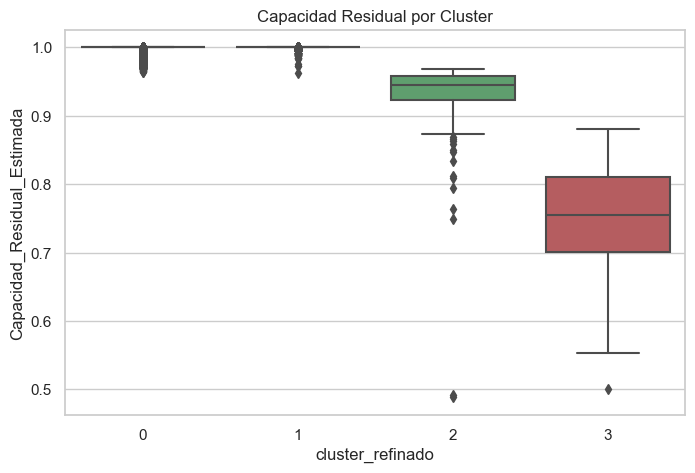

In [188]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="cluster_refinado",
    y="Capacidad_Residual_Estimada",
    data=df_features
)
plt.title("Capacidad Residual por Cluster")
plt.show()

In [189]:
# 7.2 Relación entre Simultaneidad Contractual y Carga Vigente por Cluster  

In [190]:
if "cluster_refinado" in df_features.columns:
    cluster_col = "cluster_refinado"
else:
    cluster_col = "cluster"

cluster_col

'cluster_refinado'

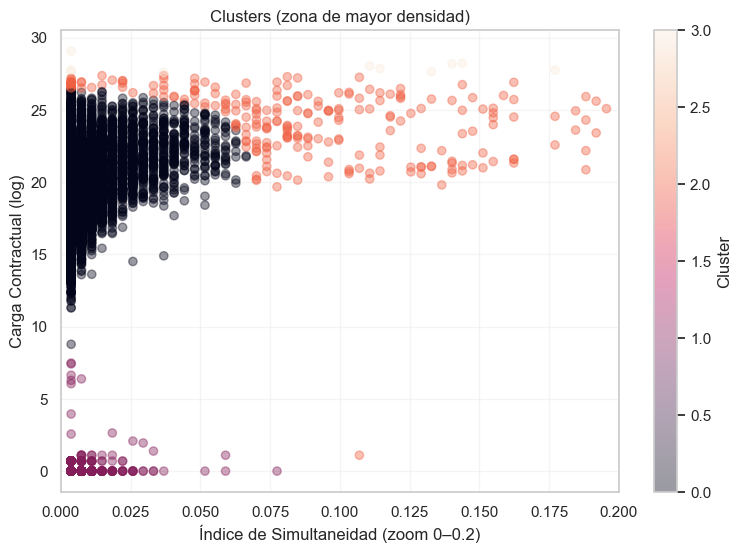

In [191]:
plt.figure(figsize=(9,6))
plt.scatter(
    df_features["Indice_Simultaneidad"],
    df_features["Carga_Log"],
    c=df_features[cluster_col],
    alpha=0.4
)
plt.xlim(0, 0.2)
plt.xlabel("Índice de Simultaneidad (zoom 0–0.2)")
plt.ylabel("Carga Contractual (log)")
plt.title("Clusters (zona de mayor densidad)")
plt.colorbar(label="Cluster")
plt.grid(True, alpha=0.2)
plt.show()

In [192]:
# 7.3 Clasificación de Proveedores Según el Riesgo

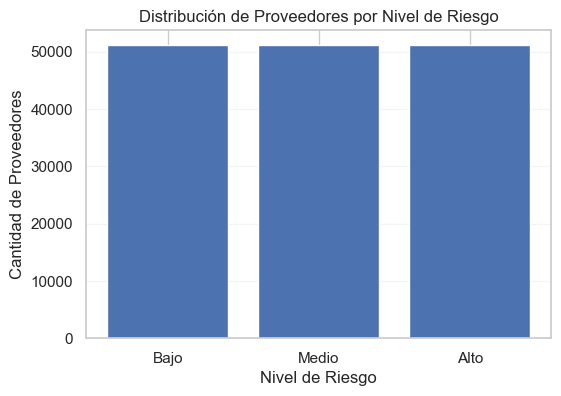

In [200]:
orden = ["Bajo", "Medio", "Alto"]

conteo = df_features["Nivel_Riesgo"].value_counts().reindex(orden)

plt.figure(figsize=(6,4))
plt.bar(conteo.index, conteo.values)

plt.title("Distribución de Proveedores por Nivel de Riesgo")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Cantidad de Proveedores")

plt.grid(True, axis="y", alpha=0.2)

plt.show()

In [194]:
# 7.4 Analisis de Concentración Contractual por Cluster

In [201]:
total_proveedores = len(df_features)

tabla_size = (
    df_features.groupby("cluster_refinado")
    .size()
    .reset_index(name="Cantidad_Proveedores")
)

tabla_size["%_Proveedores"] = (
    tabla_size["Cantidad_Proveedores"] / total_proveedores * 100
)

tabla_size

,cluster_refinado,Cantidad_Proveedores,%_Proveedores
0,0,150525,98.038258
1,1,2735,1.781330
2,2,263,0.171294
3,3,14,0.009118


In [202]:
total_carga = df_features["Carga_Contractual_Vigente"].sum()

tabla_carga = (
    df_features.groupby("cluster_refinado")["Carga_Contractual_Vigente"]
    .sum()
    .reset_index()
)

tabla_carga["%_Carga_Total"] = (
    tabla_carga["Carga_Contractual_Vigente"] / total_carga * 100
)

tabla_carga

,cluster_refinado,Carga_Contractual_Vigente,%_Carga_Total
0,0,66516632370858,5.263354e+01
1,1,5956,4.712887e-09
2,2,38887909961596,3.077138e+01
3,3,20972338495053,1.659508e+01


In [203]:
tabla_final = tabla_size.merge(tabla_carga, on="cluster_refinado")

tabla_final

,cluster_refinado,Cantidad_Proveedores,%_Proveedores,Carga_Contractual_Vigente,%_Carga_Total
0,0,150525,98.038258,66516632370858,5.263354e+01
1,1,2735,1.781330,5956,4.712887e-09
2,2,263,0.171294,38887909961596,3.077138e+01
3,3,14,0.009118,20972338495053,1.659508e+01


In [204]:
df_powerbi = df_features[
    [
        "Proveedor Adjudicado",
        "Num_Contratos_Vigentes",
        "Carga_Contractual_Vigente",
        "Indice_Simultaneidad",
        "Indice_Concentracion",
        "Saturacion_Contractual",
        "Capacidad_Residual_Estimada",
        "cluster_refinado",
        "Nivel_Riesgo"
    ]
].copy()

df_powerbi.to_csv("dataset_powerbi_actualizado.csv", index=False)

print("Archivo actualizado exportado correctamente")

Archivo actualizado exportado correctamente


In [205]:
df_features.to_csv("datos_secop_procesados.csv", index=False)